# EDA — Biohub: Cell Tracking During Development (versión Kaggle)

Este notebook está pensado para correr **dentro de Kaggle**, no en Colab. Los datos de la
competencia se montan en `/kaggle/input/...` en modo solo lectura, así que no se descarga nada ni
se necesita token de la API.

**Cómo correrlo**

1. Aceptar las reglas de la competencia (*Join Competition*).
2. En la pestaña **Code** de la competencia → **New Notebook** → *File → Import Notebook* y subir este archivo.
3. Verificar que en el panel derecho, sección **Input**, aparezca la competencia
   (si no, *Add Input* → buscar `biohub-cell-tracking-during-development`).
4. *Settings → Internet: On* (solo para instalar `zarr>=3`; requiere cuenta verificada por teléfono).
5. *Run All*. No necesita GPU.

Para correrlo fuera de Kaggle basta con definir la variable de entorno `BIOHUB_DATA` apuntando a
una carpeta con la misma estructura (`train/*.zarr`, `train/*.geff`).

In [2]:
# zarr>=3 es obligatorio: los arreglos usan la especificación Zarr v3 (zarr.json, chunks en c/i/j/k/l).
# La imagen de Kaggle puede traer zarr 2.x; solo se instala si hace falta (requiere Internet: On).
import importlib.metadata as _md
try:
    _zv = _md.version("zarr")
except _md.PackageNotFoundError:
    _zv = "0"
if int(_zv.split(".")[0]) < 3:
    !pip install -q --upgrade "zarr>=3"

In [3]:
import os, json, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("zarr", zarr.__version__, "| pandas", pd.__version__)

zarr 3.4.1 | pandas 2.3.3


In [4]:
COMPETITION = "biohub-cell-tracking-during-development"


def encontrar_datos():
    """Ubica la carpeta de la competencia montada por Kaggle.

    Según la versión del entorno, Kaggle la monta en /kaggle/input/<nombre> o en
    /kaggle/input/competitions/<nombre>; se prueban ambas y, por si acaso, cualquier
    carpeta de /kaggle/input que contenga un train/."""
    if os.environ.get("BIOHUB_DATA"):
        return Path(os.environ["BIOHUB_DATA"])
    raiz = Path("/kaggle/input")
    candidatos = [raiz / COMPETITION, raiz / "competitions" / COMPETITION]
    candidatos += [p.parent for p in raiz.glob("*/train")] + [p.parent for p in raiz.glob("*/*/train")]
    for c in candidatos:
        if (c / "train").is_dir():
            return c
    raise FileNotFoundError(
        "No se encontró la competencia en /kaggle/input. Agrégala en el panel 'Input' del notebook.")


DATA_DIR  = encontrar_datos()
TRAIN_DIR = DATA_DIR / "train"

# Con los datos montados ya no hay costo de descarga: se pueden usar TODAS las muestras.
# Poner un número para limitar (p. ej. 15) si se quiere iterar más rápido.
SAMPLES_PER_EMBRYO = None   # None = todas las muestras de cada embrión
IMAGE_BUDGET_MB    = 250    # tope de memoria para el volumen de imagen que se carga

# Escala física del vóxel (Z, Y, X) en micras/píxel, documentada por los organizadores.
VOXEL_UM = np.array([1.625, 0.40625, 0.40625])

print("Datos en:", DATA_DIR)
print("Contenido:", sorted(p.name for p in DATA_DIR.iterdir()))

Datos en: /kaggle/input/competitions/biohub-cell-tracking-during-development
Contenido: ['sample_submission.csv', 'test', 'train']


In [5]:
# --- Selección de muestras ---------------------------------------------------
# Una muestra es válida si tiene su imagen (.zarr) y su grafo (.geff) pareados.
# test/ contiene copias de train sin anotaciones, así que no se usa en el EDA.
zarr_stems = {p.name[:-5] for p in TRAIN_DIR.glob("*.zarr")}
geff_stems = {p.name[:-5] for p in TRAIN_DIR.glob("*.geff")}
paired = sorted(zarr_stems & geff_stems)

print(f".zarr: {len(zarr_stems)} | .geff: {len(geff_stems)} | pareadas: {len(paired)}")
if zarr_stems ^ geff_stems:
    print("Sin pareja (se excluyen):", sorted(zarr_stems ^ geff_stems)[:10])

by_embryo = defaultdict(list)
for stem in paired:
    by_embryo[stem.split("_")[0]].append(stem)

SAMPLES = []
for embryo in sorted(by_embryo, key=lambda e: -len(by_embryo[e])):
    SAMPLES += sorted(by_embryo[embryo])[:SAMPLES_PER_EMBRYO]

print(f"\nMuestras disponibles por embrión:")
for e, s in sorted(by_embryo.items(), key=lambda kv: -len(kv[1])):
    print(f"  {e}: {len(s)}")
print(f"\nMuestras seleccionadas: {len(SAMPLES)}")

.zarr: 199 | .geff: 199 | pareadas: 199

Muestras disponibles por embrión:
  6bba: 128
  44b6: 71

Muestras seleccionadas: 199


In [6]:
# --- Lectura de imagen (.zarr) y grafo (.geff) -------------------------------
def tiene_meta(d):
    return (Path(d) / "zarr.json").exists() or (Path(d) / ".zarray").exists()


def zarr_json(path):
    """Lee la metadata de un arreglo zarr (v3: zarr.json, v2: .zarray)."""
    p3, p2 = Path(path) / "zarr.json", Path(path) / ".zarray"
    if p3.exists():
        m = json.loads(p3.read_text())
        if m.get("node_type") == "group":
            return None
        return {"shape": tuple(m["shape"]),
                "dtype": str(m.get("data_type", m.get("dtype"))),
                "chunks": tuple(m["chunk_grid"]["configuration"]["chunk_shape"]),
                "encoding": m.get("chunk_key_encoding", {"name": "default"}),
                "raw": m}
    if p2.exists():
        m = json.loads(p2.read_text())
        return {"shape": tuple(m["shape"]), "dtype": str(m["dtype"]),
                "chunks": tuple(m["chunks"]),
                "encoding": {"name": "v2", "configuration": {"separator": "."}},
                "raw": m}
    return None


def image_levels(stem):
    """Niveles de la pirámide multiescala disponibles, con su metadata."""
    root = TRAIN_DIR / f"{stem}.zarr"
    out = {}
    if not root.exists():
        return out
    for d in sorted(root.iterdir()):
        if d.is_dir():
            m = zarr_json(d)
            if m:
                out[d.name] = m
    return out


def read_geff(stem):
    """Lee un grafo .geff -> (atributos, ids de nodo, props dict, aristas)."""
    g = TRAIN_DIR / f"{stem}.geff"
    attrs = {}
    try:
        attrs = dict(zarr.open_group(str(g), mode="r").attrs)
    except Exception:
        pass

    node_ids = np.asarray(zarr.open(str(g / "nodes" / "ids"), mode="r")[:])
    props = {}
    for name in ("t", "z", "y", "x"):
        p = g / "nodes" / "props" / name / "values"
        if tiene_meta(p):
            props[name] = np.asarray(zarr.open(str(p), mode="r")[:]).astype(float)
        else:
            print(f"AVISO: {stem} no tiene la propiedad '{name}'")
            props[name] = np.full(node_ids.shape[0], np.nan)

    ep = g / "edges" / "ids"
    edges = np.asarray(zarr.open(str(ep), mode="r")[:]) if tiene_meta(ep) else np.zeros((0, 2), int)
    return attrs, node_ids, props, edges


def find_key(d, key):
    """Busca una llave recursivamente en atributos anidados."""
    if not isinstance(d, dict):
        return None
    if key in d:
        return d[key]
    for v in d.values():
        r = find_key(v, key)
        if r is not None:
            return r
    return None

In [7]:
# --- Control de calidad de las muestras --------------------------------------
# Ya no puede haber descargas incompletas, pero se mantiene una verificación de
# coherencia por si alguna muestra viene mal desde el origen.
ARRAYS_REQ = ["nodes/ids", "edges/ids"] + [f"nodes/props/{n}/values" for n in ("t", "z", "y", "x")]


def muestra_valida(s):
    base = TRAIN_DIR / f"{s}.geff"
    falta = [r for r in ARRAYS_REQ if not tiene_meta(base / r)]
    if falta:
        return False, f"faltan arreglos {falta}"
    try:
        _, ids, props, edges = read_geff(s)
        if len(ids) == 0:
            return False, "sin nodos"
        if len(np.unique(ids)) < len(ids) * 0.9:
            return False, "ids repetidos"
        if np.nanmax(props["t"]) == np.nanmin(props["t"]):
            return False, "t constante"
    except Exception as e:
        return False, str(e)[:50]
    return True, "ok"


validas, descartadas = [], {}
for s in tqdm(SAMPLES, desc="Validando"):
    ok, razon = muestra_valida(s)
    (validas.append(s) if ok else descartadas.update({s: razon}))

print(f"Muestras válidas: {len(validas)} de {len(SAMPLES)}")
for s, r in list(descartadas.items())[:10]:
    print(f"  descartada {s}: {r}")

SAMPLES = validas
assert SAMPLES, "No quedó ninguna muestra válida."
print(f"\nSAMPLES = {len(SAMPLES)} muestras | embriones: "
      f"{sorted({s.split('_')[0] for s in SAMPLES})}")

Validando:   0%|          | 0/199 [00:00<?, ?it/s]

Muestras válidas: 199 de 199

SAMPLES = 199 muestras | embriones: ['44b6', '6bba']


In [8]:
# --- Construcción de las tres tablas ----------------------------------------
node_rows, edge_rows, sample_rows = [], [], []

for stem in tqdm(SAMPLES, desc="Construyendo tablas"):
    embryo = stem.split("_")[0]
    attrs, ids, props, edges = read_geff(stem)

    n = len(ids)
    idx = {int(v): i for i, v in enumerate(ids)}          # id de nodo -> posición
    indeg, outdeg = np.zeros(n, int), np.zeros(n, int)

    e_src = np.array([idx[int(a)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    e_dst = np.array([idx[int(b)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    for i in e_src:
        outdeg[i] += 1
    for i in e_dst:
        indeg[i] += 1

    nodes = pd.DataFrame({
        "sample": stem, "embryo_id": embryo, "node_id": ids,
        "t": props["t"], "z": props["z"], "y": props["y"], "x": props["x"],
        "in_degree": indeg, "out_degree": outdeg,
    })
    nodes["z_um"] = nodes["z"] * VOXEL_UM[0]
    nodes["y_um"] = nodes["y"] * VOXEL_UM[1]
    nodes["x_um"] = nodes["x"] * VOXEL_UM[2]
    nodes["es_division"] = nodes["out_degree"] >= 2
    nodes["tipo_temporal"] = np.select(
        [(nodes.in_degree == 0) & (nodes.out_degree == 0),
         nodes.in_degree == 0,
         nodes.out_degree == 0],
        ["aislado", "inicio", "fin"], default="intermedio")
    node_rows.append(nodes)

    if len(e_src):
        a, b = nodes.iloc[e_src].reset_index(drop=True), nodes.iloc[e_dst].reset_index(drop=True)
        d = np.stack([(b.z_um - a.z_um), (b.y_um - a.y_um), (b.x_um - a.x_um)], 1)
        edge_rows.append(pd.DataFrame({
            "sample": stem, "embryo_id": embryo,
            "t_origen": a.t.values, "dt": (b.t - a.t).values,
            "dz_um": d[:, 0], "dy_um": d[:, 1], "dx_um": d[:, 2],
            "dist_um": np.linalg.norm(d, axis=1),
            "out_degree_origen": a.out_degree.values,
        }))

    lvls = image_levels(stem)
    lvl0 = lvls.get("0") or (list(lvls.values())[0] if lvls else None)
    shape0 = lvl0["shape"] if lvl0 else (np.nan,) * 4

    sample_rows.append({
        "sample": stem, "embryo_id": embryo, "field_of_view": "_".join(stem.split("_")[1:]),
        "T": shape0[0], "Z": shape0[1], "Y": shape0[2], "X": shape0[3],
        "dtype": lvl0["dtype"] if lvl0 else None,
        "n_niveles_piramide": len(lvls),
        "n_nodos": n, "n_aristas": len(e_src),
        "t_min": np.nanmin(props["t"]) if n else np.nan,
        "t_max": np.nanmax(props["t"]) if n else np.nan,
        "n_t_anotados": len(np.unique(props["t"])) if n else 0,
        "n_divisiones": int((outdeg >= 2).sum()),
        "estimated_number_of_nodes": find_key(attrs, "estimated_number_of_nodes"),
    })

EDGE_COLS = ["sample", "embryo_id", "t_origen", "dt", "dz_um", "dy_um", "dx_um",
             "dist_um", "out_degree_origen"]
df_nodes = pd.concat(node_rows, ignore_index=True)
df_edges = (pd.concat(edge_rows, ignore_index=True) if edge_rows
            else pd.DataFrame(columns=EDGE_COLS).astype(float))
df_samples = pd.DataFrame(sample_rows)

# Variables derivadas a nivel de muestra
df_samples["cobertura_temporal"] = df_samples["n_t_anotados"] / df_samples["T"]
df_samples["nodos_por_t"] = df_samples["n_nodos"] / df_samples["n_t_anotados"]
df_samples["aristas_por_nodo"] = df_samples["n_aristas"] / df_samples["n_nodos"]
df_samples["tasa_division"] = df_samples["n_divisiones"] / df_samples["n_nodos"]

print(f"df_samples: {df_samples.shape} | df_nodes: {df_nodes.shape} | df_edges: {df_edges.shape}")
df_samples

Construyendo tablas:   0%|          | 0/199 [00:00<?, ?it/s]

df_samples: (199, 20) | df_nodes: (133318, 14) | df_edges: (128883, 9)


,sample,embryo_id,field_of_view,T,Z,Y,X,dtype,n_niveles_piramide,n_nodos,n_aristas,t_min,t_max,n_t_anotados,n_divisiones,estimated_number_of_nodes,cobertura_temporal,nodos_por_t,aristas_por_nodo,tasa_division
0,6bba_05b6850b,6bba,05b6850b,100,64,256,256,uint16,1,861,845,0.0,99.0,100,0,6362,1.00,8.610000,0.981417,0.000000
1,6bba_05db0fb1,6bba,05db0fb1,100,64,256,256,uint16,1,1229,1183,0.0,99.0,100,3,69800,1.00,12.290000,0.962571,0.002441
2,6bba_062c8d37,6bba,062c8d37,100,64,256,256,uint16,1,930,898,0.0,99.0,99,1,6030,0.99,9.393939,0.965591,0.001075
3,6bba_07477033,6bba,07477033,100,64,256,256,uint16,1,613,602,0.0,99.0,100,0,4836,1.00,6.130000,0.982055,0.000000
4,6bba_07e24132,6bba,07e24132,100,64,256,256,uint16,1,359,345,0.0,99.0,100,2,21485,1.00,3.590000,0.961003,0.005571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,44b6_e31261b4,44b6,e31261b4,100,64,256,256,uint16,1,116,113,15.0,96.0,82,0,72856,0.82,1.414634,0.974138,0.000000
195,44b6_e35b117d,44b6,e35b117d,100,64,256,256,uint16,1,270,266,0.0,99.0,100,0,28641,1.00,2.700000,0.985185,0.000000
196,44b6_e57ff5c6,44b6,e57ff5c6,100,64,256,256,uint16,1,193,186,0.0,99.0,100,0,20314,1.00,1.930000,0.963731,0.000000
197,44b6_eb2880fc,44b6,eb2880fc,100,64,256,256,uint16,1,390,379,0.0,99.0,100,1,48084,1.00,3.900000,0.971795,0.002564


In [9]:
for nombre, d in [("df_samples", df_samples), ("df_nodes", df_nodes), ("df_edges", df_edges)]:
    print(f"\n=== {nombre}: {d.shape[0]} observaciones x {d.shape[1]} variables ===")
    print(pd.DataFrame({
        "tipo": d.dtypes.astype(str),
        "n_unicos": d.nunique(),
        "n_faltantes": d.isna().sum(),
        "% faltante": (d.isna().mean() * 100).round(2),
    }))


=== df_samples: 199 observaciones x 20 variables ===
                              tipo  n_unicos  n_faltantes  % faltante
sample                      object       199            0         0.0
embryo_id                   object         2            0         0.0
field_of_view               object       199            0         0.0
T                            int64         1            0         0.0
Z                            int64         1            0         0.0
Y                            int64         1            0         0.0
X                            int64         1            0         0.0
dtype                       object         1            0         0.0
n_niveles_piramide           int64         1            0         0.0
n_nodos                      int64       184            0         0.0
n_aristas                    int64       177            0         0.0
t_min                      float64        21            0         0.0
t_max                      float64  

In [10]:
# Clasificación conceptual de las variables (para el informe)
tipos = pd.DataFrame([
    ("sample",        "categórica nominal", "identificador de la muestra (embrión + field of view)"),
    ("embryo_id",     "categórica nominal", "embrión de origen; permite comparar entre individuos"),
    ("t",             "numérica discreta",  "índice de instante temporal (frame)"),
    ("z, y, x",       "numérica continua",  "coordenada del centroide en píxeles del nivel 0"),
    ("z_um, y_um, x_um", "numérica continua", "misma coordenada en micras (escala física)"),
    ("in_degree",     "numérica discreta",  "aristas entrantes: 0 = aparición o inicio de la anotación"),
    ("out_degree",    "numérica discreta",  "aristas salientes: 2 = división celular"),
    ("es_division",   "categórica binaria", "el nodo se divide en el siguiente frame"),
    ("tipo_temporal", "categórica nominal", "inicio / intermedio / fin / aislado dentro de la trayectoria"),
    ("dt",            "numérica discreta",  "salto temporal del enlace (frames)"),
    ("dist_um",       "numérica continua",  "desplazamiento 3D del enlace en micras"),
], columns=["variable", "tipo", "descripción"])
tipos

,variable,tipo,descripción
0,sample,categórica nominal,identificador de la muestra (embrión + field o...
1,embryo_id,categórica nominal,embrión de origen; permite comparar entre indi...
2,t,numérica discreta,índice de instante temporal (frame)
3,"z, y, x",numérica continua,coordenada del centroide en píxeles del nivel 0
4,"z_um, y_um, x_um",numérica continua,misma coordenada en micras (escala física)
5,in_degree,numérica discreta,aristas entrantes: 0 = aparición o inicio de l...
6,out_degree,numérica discreta,aristas salientes: 2 = división celular
7,es_division,categórica binaria,el nodo se divide en el siguiente frame
8,tipo_temporal,categórica nominal,inicio / intermedio / fin / aislado dentro de ...
9,dt,numérica discreta,salto temporal del enlace (frames)


In [11]:
# --- Validaciones de integridad ---------------------------------------------
print("Nodos duplicados (sample, node_id):", df_nodes.duplicated(["sample", "node_id"]).sum())
print("Aristas con dt <= 0:", int((df_edges["dt"] <= 0).sum()))
print("Distribución de dt:\n", df_edges["dt"].value_counts().head())

# Con todas las muestras la lista por muestra es muy larga: se resume.
lim = df_samples.set_index("sample")[["Z", "Y", "X"]]
fuera_por_muestra = {}
for s, g in df_nodes.groupby("sample"):
    if s in lim.index and lim.loc[s].notna().all():
        fuera_por_muestra[s] = int(((g.z < 0) | (g.z >= lim.loc[s, "Z"]) |
                                    (g.y < 0) | (g.y >= lim.loc[s, "Y"]) |
                                    (g.x < 0) | (g.x >= lim.loc[s, "X"])).sum())
fuera = pd.Series(fuera_por_muestra, dtype=int)
print(f"\nCoordenadas fuera del volumen de imagen: {fuera.sum()} nodos "
      f"en {(fuera > 0).sum()} de {len(fuera)} muestras")
if (fuera > 0).any():
    print(fuera[fuera > 0].sort_values(ascending=False).head(10).to_string())

print("\nFaltantes por columna en df_nodes:")
print(df_nodes.isna().sum()[lambda s: s > 0] if df_nodes.isna().any().any() else "  ninguno")

Nodos duplicados (sample, node_id): 0
Aristas con dt <= 0: 0
Distribución de dt:
 dt
1.0    128883
Name: count, dtype: int64

Coordenadas fuera del volumen de imagen: 0 nodos en 0 de 199 muestras

Faltantes por columna en df_nodes:
  ninguno


In [12]:
print("=== Nivel muestra ===")
cols_s = ["T", "Z", "Y", "X", "n_nodos", "n_aristas", "n_t_anotados", "cobertura_temporal",
          "nodos_por_t", "aristas_por_nodo", "tasa_division"]
cols_s += [c for c in ["densidad_anotacion"] if c in df_samples]
display(df_samples[cols_s].describe().T.round(3))

print("\n=== Nivel nodo ===")
display(df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]].describe().T.round(3))

print("\n=== Nivel arista ===")
display(df_edges[["dt", "dz_um", "dy_um", "dx_um", "dist_um"]].describe().T.round(3))

=== Nivel muestra ===


,count,mean,std,min,25%,50%,75%,max
T,199.0,100.000,0.000,100.000,100.000,100.000,100.000,100.000
Z,199.0,64.000,0.000,64.000,64.000,64.000,64.000,64.000
Y,199.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
X,199.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
n_nodos,199.0,669.940,421.410,50.000,294.000,659.000,939.500,1950.000
n_aristas,199.0,647.653,406.298,49.000,286.000,639.000,918.500,1879.000
n_t_anotados,199.0,95.141,11.730,40.000,99.000,100.000,100.000,100.000
cobertura_temporal,199.0,0.951,0.117,0.400,0.990,1.000,1.000,1.000
nodos_por_t,199.0,6.888,4.274,1.000,3.015,6.610,9.445,20.052
aristas_por_nodo,199.0,0.970,0.015,0.916,0.961,0.973,0.982,0.994



=== Nivel nodo ===


,count,mean,std,min,25%,50%,75%,max
t,133318.0,49.735,28.054,0.0,26.000,50.000,74.000,99.000
z_um,133318.0,50.298,27.958,0.0,27.625,50.375,73.125,102.375
y_um,133318.0,51.184,27.596,0.0,29.656,51.594,72.719,103.594
x_um,133318.0,52.644,27.964,0.0,30.062,52.812,75.156,103.594
in_degree,133318.0,0.967,0.179,0.0,1.000,1.000,1.000,1.000
out_degree,133318.0,0.967,0.186,0.0,1.000,1.000,1.000,2.000



=== Nivel arista ===


,count,mean,std,min,25%,50%,75%,max
dt,128883.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
dz_um,128883.0,-0.415,1.753,-60.125,-1.625,0.000,0.000,56.875
dy_um,128883.0,0.144,1.453,-21.125,-0.406,0.000,0.812,25.594
dx_um,128883.0,-0.262,1.519,-17.875,-0.812,0.000,0.406,9.344
dist_um,128883.0,2.130,1.793,0.000,0.908,1.817,2.725,60.758


In [13]:
# Cuantiles del desplazamiento: acotan el radio de búsqueda de un algoritmo de enlace
q = df_edges.loc[df_edges.dt == 1, "dist_um"].quantile([.5, .75, .9, .95, .99, 1.0]).round(2)
print("Desplazamiento entre frames consecutivos (micras):")
print(q.to_string())
print(f"\nUn radio de busqueda de {q[0.99]:.1f} um cubriria el 99% de los enlaces reales.")

Desplazamiento entre frames consecutivos (micras):
0.50     1.82
0.75     2.73
0.90     4.14
0.95     5.34
0.99     8.38
1.00    60.76

Un radio de busqueda de 8.4 um cubriria el 99% de los enlaces reales.


In [14]:
def tabla_frecuencia(serie, nombre):
    t = pd.concat([serie.value_counts().rename("frecuencia"),
                   (serie.value_counts(normalize=True) * 100).round(2).rename("%")], axis=1)
    print(f"\n--- {nombre} ---")
    display(t)
    return t

tabla_frecuencia(df_samples["embryo_id"], "Muestras por embrión")
tabla_frecuencia(df_nodes["embryo_id"], "Nodos anotados por embrión")
tabla_frecuencia(df_nodes["tipo_temporal"], "Tipo de nodo dentro de la trayectoria")
tabla_frecuencia(df_nodes["out_degree"], "Grado de salida (2 = división)")
tabla_frecuencia(df_nodes["in_degree"], "Grado de entrada")
None


--- Muestras por embrión ---


,frecuencia,%
embryo_id,,
6bba,128,64.32
44b6,71,35.68



--- Nodos anotados por embrión ---


,frecuencia,%
embryo_id,,
6bba,113121,84.85
44b6,20197,15.15



--- Tipo de nodo dentro de la trayectoria ---


,frecuencia,%
tipo_temporal,,
intermedio,124297,93.23
fin,4586,3.44
inicio,4435,3.33



--- Grado de salida (2 = división) ---


,frecuencia,%
out_degree,,
1,128581,96.45
0,4586,3.44
2,151,0.11



--- Grado de entrada ---


,frecuencia,%
in_degree,,
1,128883,96.67
0,4435,3.33


tipo_temporal,fin,inicio,intermedio
embryo_id,,,
44b6,1.97,1.84,96.2
6bba,3.70,3.59,92.7


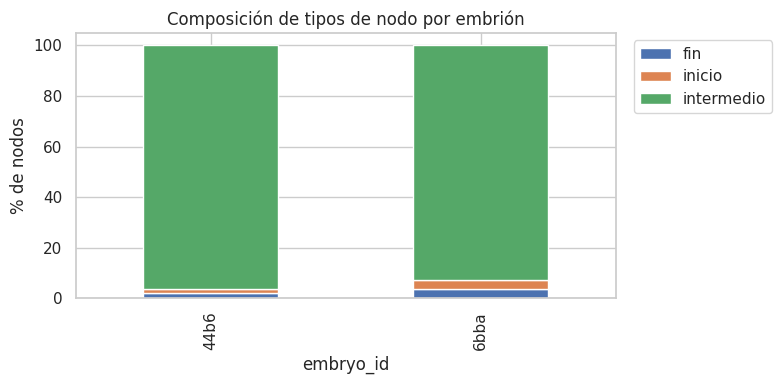

In [15]:
# Tabla cruzada: composición de tipos de nodo por embrión (proporciones por fila)
cruce = pd.crosstab(df_nodes["embryo_id"], df_nodes["tipo_temporal"], normalize="index") * 100
display(cruce.round(2))

cruce.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("% de nodos"); plt.title("Composición de tipos de nodo por embrión")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

Muestras menos anotadas:
       sample embryo_id  n_nodos  estimated_number_of_nodes  densidad_anotacion  cobertura_temporal
44b6_18ced818      44b6      100                      78644                0.13                1.00
44b6_cf2536e8      44b6       76                      57565                0.13                0.76
44b6_0b24845f      44b6       51                      32795                0.16                0.40
44b6_e31261b4      44b6      116                      72856                0.16                0.82
44b6_706092f0      44b6      118                      69898                0.17                1.00

Muestras más anotadas:
       sample embryo_id  n_nodos  estimated_number_of_nodes  densidad_anotacion  cobertura_temporal
6bba_2819ca14      6bba      986                       5534               17.82                1.00
6bba_6feeb0b1      6bba     1389                       7518               18.48                1.00
6bba_5f89039d      6bba      904                   

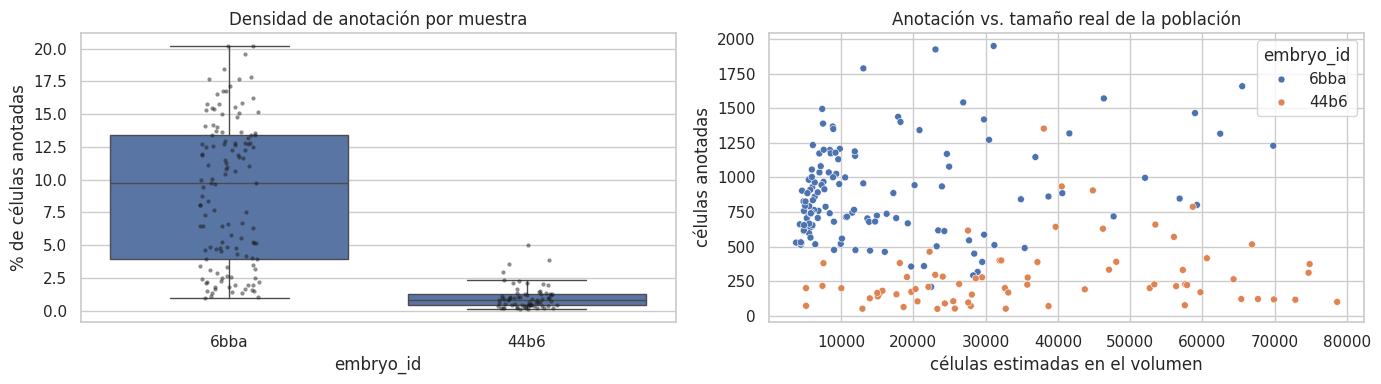

In [16]:
# --- Densidad de anotación: qué fracción de las células está etiquetada ------
df_samples["densidad_anotacion"] = (df_samples["n_nodos"] /
                                    df_samples["estimated_number_of_nodes"] * 100)

cols_d = ["sample", "embryo_id", "n_nodos", "estimated_number_of_nodes",
          "densidad_anotacion", "cobertura_temporal"]
orden_d = df_samples.sort_values("densidad_anotacion")
print("Muestras menos anotadas:")
print(orden_d[cols_d].head(5).round(2).to_string(index=False))
print("\nMuestras más anotadas:")
print(orden_d[cols_d].tail(5).round(2).to_string(index=False))

glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100
print(f"\nDensidad global: {glob:.2f}% de las células estimadas están anotadas")
print(f"Rango entre muestras: {df_samples.densidad_anotacion.min():.2f}% – "
      f"{df_samples.densidad_anotacion.max():.2f}% "
      f"(factor {df_samples.densidad_anotacion.max()/df_samples.densidad_anotacion.min():.0f}x)")
print("\nPor embrión:")
print(df_samples.groupby("embryo_id")["densidad_anotacion"].describe()[["count","mean","min","max"]].round(2))

# Con cientos de muestras un barplot por muestra es ilegible: se resume por embrión.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df_samples, x="embryo_id", y="densidad_anotacion", ax=ax[0], showfliers=False)
sns.stripplot(data=df_samples, x="embryo_id", y="densidad_anotacion", ax=ax[0],
              color="k", size=3, alpha=.5)
ax[0].set_title("Densidad de anotación por muestra"); ax[0].set_ylabel("% de células anotadas")

sns.scatterplot(data=df_samples, x="estimated_number_of_nodes", y="n_nodos",
                hue="embryo_id", ax=ax[1], s=25)
ax[1].set_xlabel("células estimadas en el volumen"); ax[1].set_ylabel("células anotadas")
ax[1].set_title("Anotación vs. tamaño real de la población")
plt.tight_layout(); plt.show()

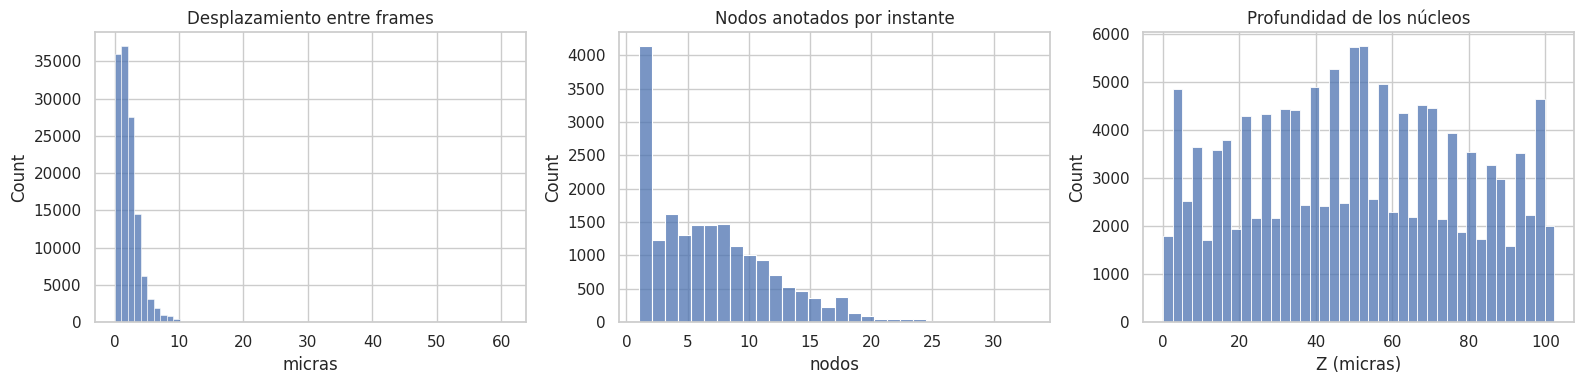

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df_edges.loc[df_edges.dt == 1, "dist_um"], bins=60, ax=ax[0])
ax[0].set_title("Desplazamiento entre frames"); ax[0].set_xlabel("micras")

nodos_t = df_nodes.groupby(["sample", "t"]).size().rename("n").reset_index()
sns.histplot(nodos_t["n"], bins=30, ax=ax[1])
ax[1].set_title("Nodos anotados por instante"); ax[1].set_xlabel("nodos")

sns.histplot(df_nodes["z_um"], bins=40, ax=ax[2])
ax[2].set_title("Profundidad de los núcleos"); ax[2].set_xlabel("Z (micras)")

plt.tight_layout(); plt.show()

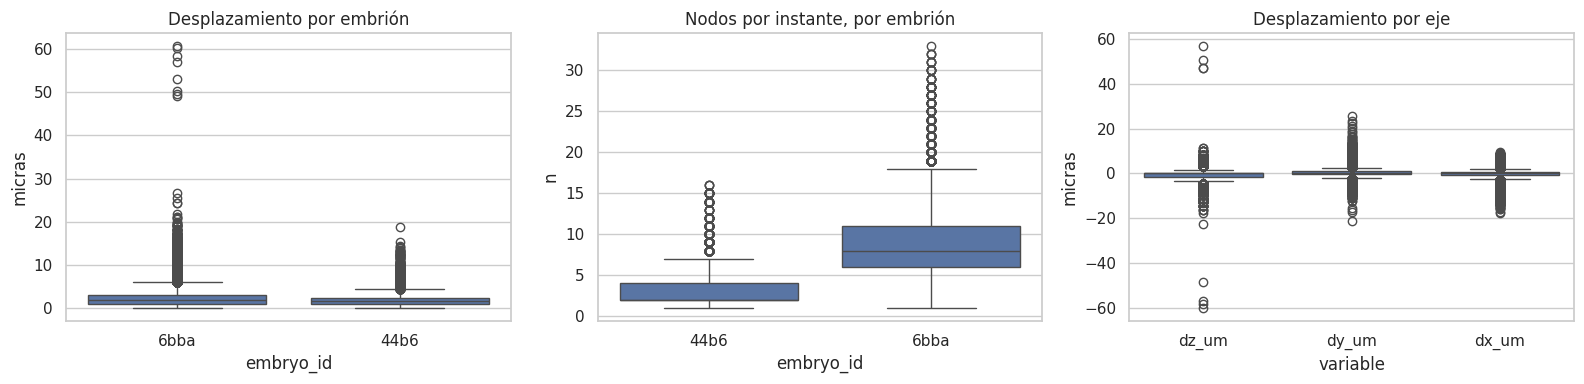

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_edges[df_edges.dt == 1], x="embryo_id", y="dist_um", ax=ax[0])
ax[0].set_title("Desplazamiento por embrión"); ax[0].set_ylabel("micras")

sns.boxplot(data=nodos_t.merge(df_samples[["sample", "embryo_id"]], on="sample"),
            x="embryo_id", y="n", ax=ax[1])
ax[1].set_title("Nodos por instante, por embrión")

sns.boxplot(data=df_edges[df_edges.dt == 1].melt(value_vars=["dz_um", "dy_um", "dx_um"]),
            x="variable", y="value", ax=ax[2])
ax[2].set_title("Desplazamiento por eje"); ax[2].set_ylabel("micras")

plt.tight_layout(); plt.show()

### 5.c Cruces entre variables

Aquí se buscan las relaciones que explican el problema: cómo evoluciona la densidad de anotación en el
tiempo, si el movimiento celular depende del instante o de la profundidad, y qué tan correlacionadas están
las variables del grafo.

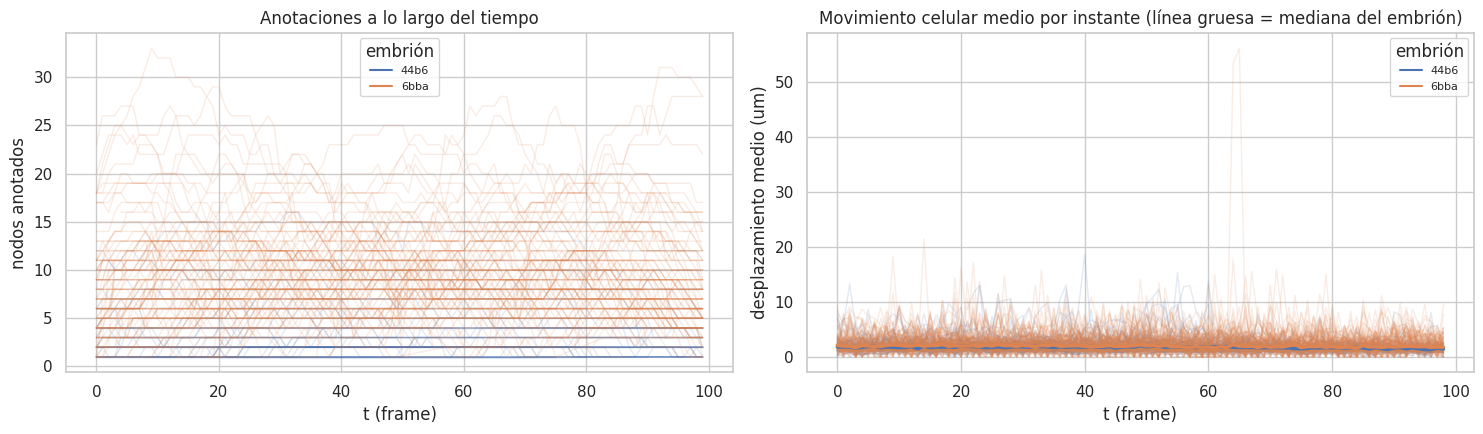

In [19]:
# Una línea por muestra, coloreada por embrión (con cientos de muestras la
# leyenda por muestra deja de ser legible).
embriones = sorted(df_samples["embryo_id"].unique())
COLOR_EMB = dict(zip(embriones, sns.color_palette(n_colors=len(embriones))))
ALPHA_LINEA = max(.15, min(1.0, 15 / len(df_samples)))


def leyenda_embriones(ax):
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([], [], color=c, label=e) for e, c in COLOR_EMB.items()],
              title="embrión", fontsize=8)


fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for s, g in nodos_t.groupby("sample"):
    ax[0].plot(g["t"], g["n"], lw=1, alpha=ALPHA_LINEA, color=COLOR_EMB[s.split("_")[0]])
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("nodos anotados")
ax[0].set_title("Anotaciones a lo largo del tiempo"); leyenda_embriones(ax[0])

mov = df_edges[df_edges.dt == 1].groupby(["sample", "t_origen"])["dist_um"].mean().reset_index()
for s, g in mov.groupby("sample"):
    ax[1].plot(g["t_origen"], g["dist_um"], lw=1, alpha=ALPHA_LINEA, color=COLOR_EMB[s.split("_")[0]])
# Mediana por embrión encima, para ver la tendencia general
for e, g in mov.assign(embryo_id=mov["sample"].str.split("_").str[0]).groupby("embryo_id"):
    m = g.groupby("t_origen")["dist_um"].median()
    ax[1].plot(m.index, m.values, lw=2.5, color=COLOR_EMB[e])
ax[1].set_xlabel("t (frame)"); ax[1].set_ylabel("desplazamiento medio (um)")
ax[1].set_title("Movimiento celular medio por instante (línea gruesa = mediana del embrión)")
leyenda_embriones(ax[1])

plt.tight_layout(); plt.show()

In [20]:
print("dt:", df_edges["dt"].value_counts(dropna=False).head(10).to_dict())
print("dt nulos:", df_edges["dt"].isna().sum(), "de", len(df_edges))
print("\nNaN en propiedades de nodos:")
print(df_nodes[["t", "z", "y", "x"]].isna().sum().to_dict())
print("\nMuestras con t nulo:")
print(df_nodes[df_nodes["t"].isna()]["sample"].value_counts().to_dict())

dt: {1.0: 128883}
dt nulos: 0 de 128883

NaN en propiedades de nodos:
{'t': 0, 'z': 0, 'y': 0, 'x': 0}

Muestras con t nulo:
{}


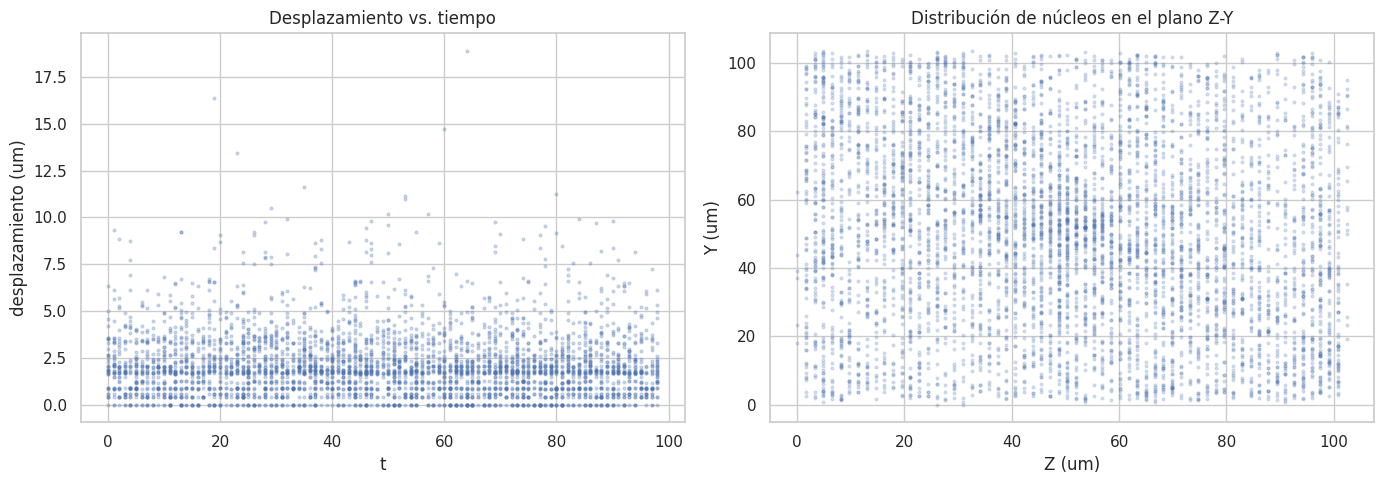

In [21]:
# Subconjunto de aristas consecutivas, con respaldo si el filtro deja poco
E1 = df_edges[df_edges["dt"] == 1]
if len(E1) == 0:
    print(f"AVISO: ninguna arista tiene dt == 1 (dt observados: "
          f"{df_edges['dt'].dropna().unique()[:5]}). Se usan todas las aristas.")
    E1 = df_edges.dropna(subset=["dist_um"])

def submuestra(df, n):
    return df.sample(min(n, len(df)), random_state=0) if len(df) else df

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sub = submuestra(E1, 4000)
ax[0].scatter(sub["t_origen"], sub["dist_um"], s=4, alpha=.25)
ax[0].set_xlabel("t"); ax[0].set_ylabel("desplazamiento (um)")
ax[0].set_title("Desplazamiento vs. tiempo")

nodos_z = submuestra(df_nodes, 6000)
ax[1].scatter(nodos_z["z_um"], nodos_z["y_um"], s=4, alpha=.2)
ax[1].set_xlabel("Z (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Distribución de núcleos en el plano Z-Y")

plt.tight_layout(); plt.show()

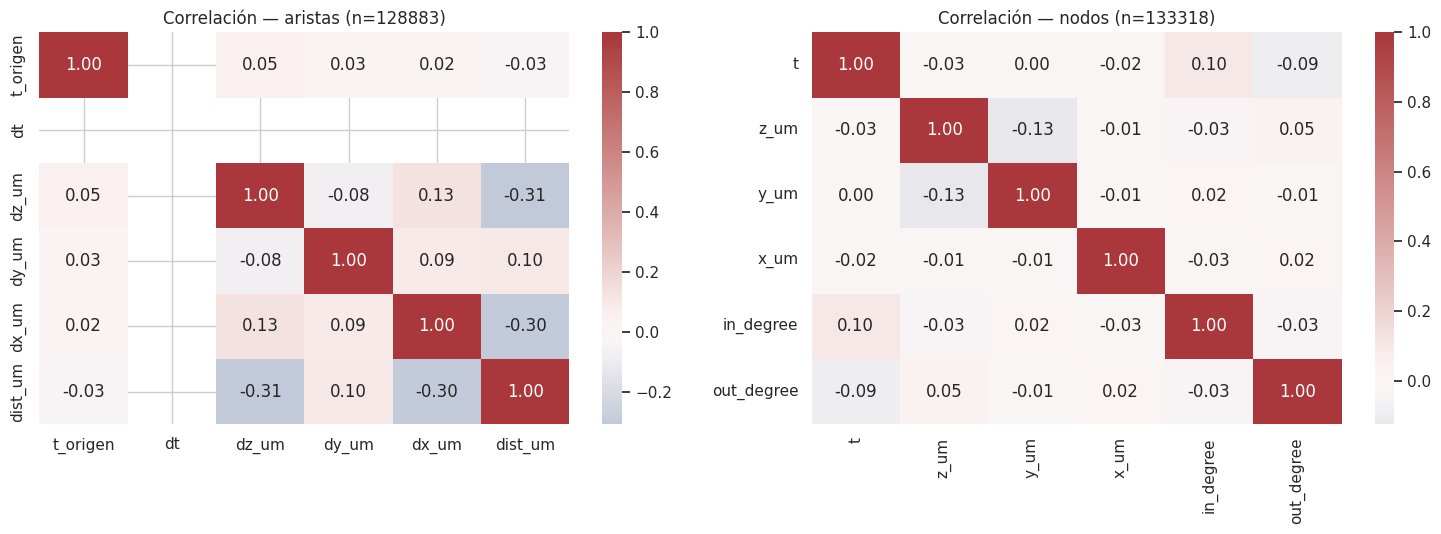

Nota: df_samples tiene solo 199 filas; sus correlaciones se reportan de forma descriptiva y no se interpretan como evidencia.


In [22]:
# Correlaciones. OJO: a nivel de muestra solo hay pocas filas, así que la matriz
# informativa es la de nivel arista/nodo, con miles de observaciones.
num_edges = df_edges[["t_origen", "dt", "dz_um", "dy_um", "dx_um", "dist_um"]]
num_nodes = df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(num_edges.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[0])
ax[0].set_title(f"Correlación — aristas (n={len(df_edges)})")
sns.heatmap(num_nodes.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[1])
ax[1].set_title(f"Correlación — nodos (n={len(df_nodes)})")
plt.tight_layout(); plt.show()

print(f"Nota: df_samples tiene solo {len(df_samples)} filas; sus correlaciones se reportan "
      "de forma descriptiva y no se interpretan como evidencia.")

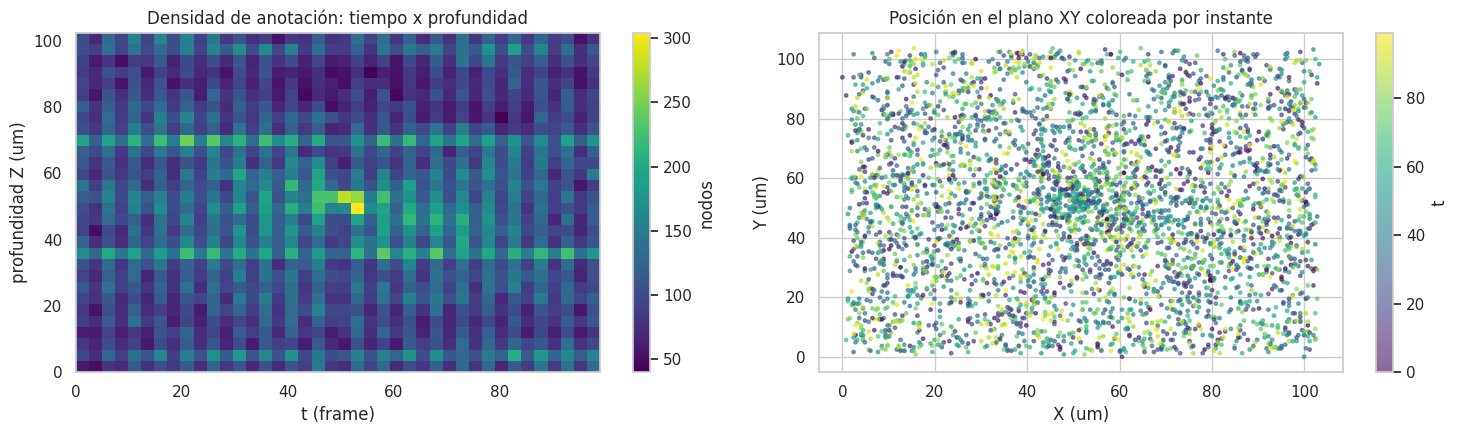

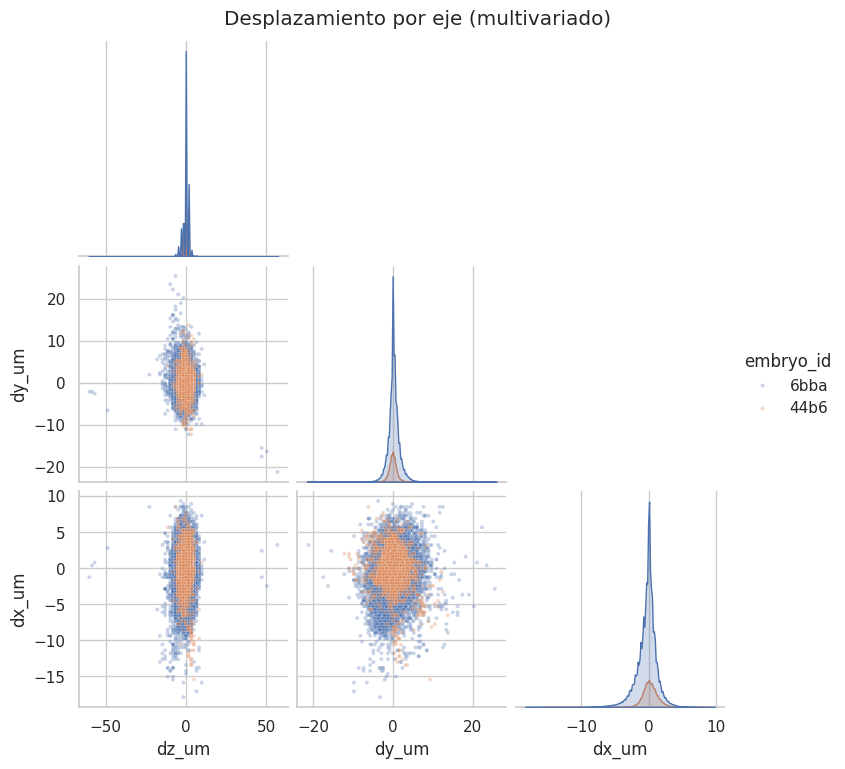

In [23]:
# --- Vistas multivariadas ----------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

h = ax[0].hist2d(df_nodes["t"], df_nodes["z_um"], bins=[40, 30], cmap="viridis")
plt.colorbar(h[3], ax=ax[0], label="nodos")
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("profundidad Z (um)")
ax[0].set_title("Densidad de anotación: tiempo x profundidad")

sub = df_nodes.sample(min(4000, len(df_nodes)), random_state=0)
sc = ax[1].scatter(sub["x_um"], sub["y_um"], c=sub["t"], s=6, alpha=.6, cmap="viridis")
plt.colorbar(sc, ax=ax[1], label="t")
ax[1].set_xlabel("X (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Posición en el plano XY coloreada por instante")
plt.tight_layout(); plt.show()

# Relación conjunta de las tres componentes del desplazamiento
g = sns.pairplot(df_edges[df_edges.dt == 1][["dz_um", "dy_um", "dx_um", "embryo_id"]],
                 hue="embryo_id", corner=True, plot_kws=dict(s=8, alpha=.3))
g.figure.suptitle("Desplazamiento por eje (multivariado)", y=1.02)
plt.show()

In [24]:
e1 = df_edges[df_edges.dt == 1]
q1, q3 = e1["dist_um"].quantile([.25, .75])
lim_sup = q3 + 1.5 * (q3 - q1)
out = e1[e1.dist_um > lim_sup]

print(f"Límite de Tukey: {lim_sup:.2f} um")
print(f"Atípicos: {len(out)} de {len(e1)} ({100*len(out)/len(e1):.2f}%)")
print(f"Máximo observado: {e1.dist_um.max():.2f} um")
print("\nAtípicos por embrión (%):")
print((out.groupby("embryo_id").size() / e1.groupby("embryo_id").size() * 100).round(2).to_string())
print("\nAtípicos por tipo de origen: divisiones vs. no divisiones")
print(pd.crosstab(e1.out_degree_origen >= 2, e1.dist_um > lim_sup, normalize="index").round(3))

Límite de Tukey: 5.45 um
Atípicos: 6060 de 128883 (4.70%)
Máximo observado: 60.76 um

Atípicos por embrión (%):
embryo_id
44b6    2.12
6bba    5.17

Atípicos por tipo de origen: divisiones vs. no divisiones
dist_um            False  True 
out_degree_origen              
False              0.954  0.046
True               0.457  0.543


Divisiones: 151 de 133318 nodos (0.113%)

Por embrión:
           muestras   nodos  divisiones  muestras_con_division  tasa_division
embryo_id                                                                    
44b6             71   20197          26                     21         0.0013
6bba            128  113121         125                     66         0.0011


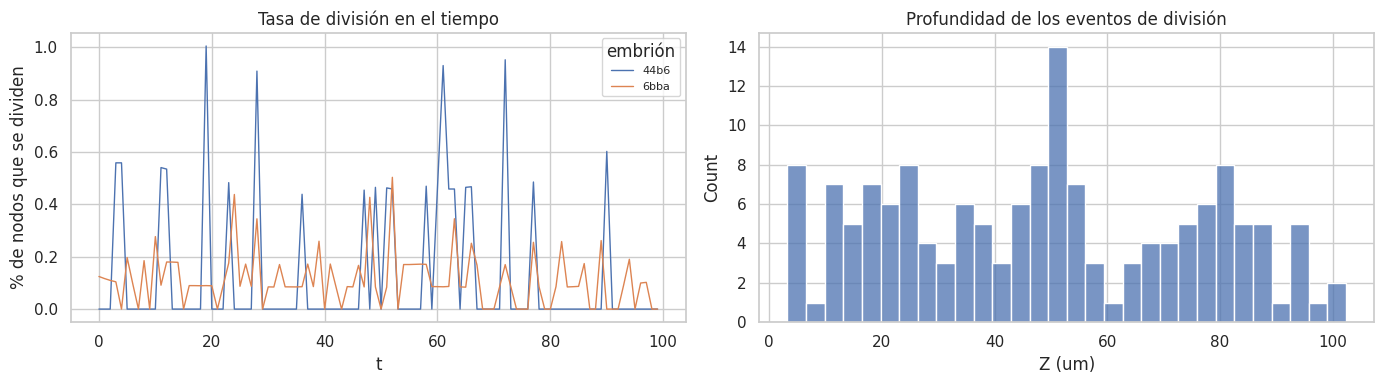

In [25]:
div = df_nodes[df_nodes.es_division]
print(f"Divisiones: {len(div)} de {len(df_nodes)} nodos ({100*len(div)/len(df_nodes):.3f}%)")
print("\nPor embrión:")
print(df_samples.groupby("embryo_id").agg(muestras=("sample", "size"),
                                          nodos=("n_nodos", "sum"),
                                          divisiones=("n_divisiones", "sum"),
                                          muestras_con_division=("n_divisiones", lambda x: (x > 0).sum()))
      .assign(tasa_division=lambda d: d.divisiones / d.nodos).round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
# Tasa agregada por instante y embrión: por muestra hay tan pocas divisiones que
# la curva individual es casi siempre 0.
tasa = (df_nodes.groupby(["embryo_id", "t"])["es_division"].mean() * 100).reset_index()
for e, g in tasa.groupby("embryo_id"):
    ax[0].plot(g["t"], g["es_division"], lw=1, color=COLOR_EMB[e], label=e)
ax[0].set_xlabel("t"); ax[0].set_ylabel("% de nodos que se dividen")
ax[0].set_title("Tasa de división en el tiempo"); ax[0].legend(title="embrión", fontsize=8)

if len(div):
    sns.histplot(div["z_um"], bins=30, ax=ax[1])
    ax[1].set_title("Profundidad de los eventos de división"); ax[1].set_xlabel("Z (um)")
plt.tight_layout(); plt.show()

Linajes: 4435


,count,mean,std,min,25%,50%,75%,max
n_nodos,4435.0,30.06,25.54,2.0,12.0,21.0,39.0,187.0
duracion,4435.0,29.52,24.26,2.0,12.0,21.0,38.5,100.0
n_divisiones,4435.0,0.03,0.18,0.0,0.0,0.0,0.0,1.0


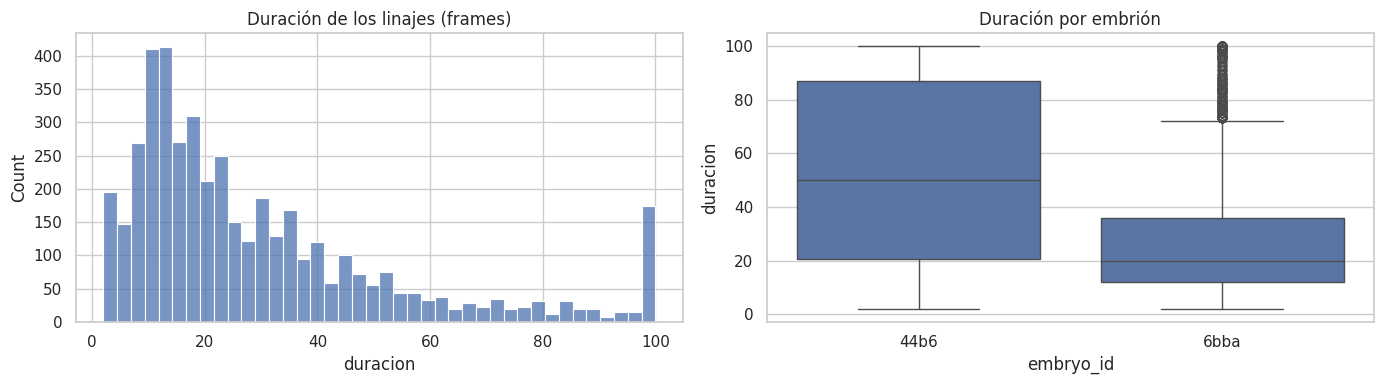

In [26]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

filas = []
for s, g in df_nodes.groupby("sample"):
    g = g.reset_index(drop=True)
    pos = {int(v): i for i, v in enumerate(g.node_id)}
    _, ids, _, edges = read_geff(s)
    src = np.array([pos[int(a)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    dst = np.array([pos[int(b)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    m = coo_matrix((np.ones(len(src)), (src, dst)), shape=(len(g), len(g)))
    n_comp, etiqueta = connected_components(m, directed=False)
    g["linaje"] = etiqueta
    filas.append(g.groupby("linaje").agg(sample=("sample", "first"),
                                         embryo_id=("embryo_id", "first"),
                                         n_nodos=("t", "size"),
                                         duracion=("t", lambda x: x.max() - x.min() + 1),
                                         n_divisiones=("es_division", "sum")).reset_index())

df_linajes = pd.concat(filas, ignore_index=True)
print(f"Linajes: {len(df_linajes)}")
display(df_linajes[["n_nodos", "duracion", "n_divisiones"]].describe().T.round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_linajes["duracion"], bins=40, ax=ax[0])
ax[0].set_title("Duración de los linajes (frames)")
sns.boxplot(data=df_linajes, x="embryo_id", y="duracion", ax=ax[1])
ax[1].set_title("Duración por embrión")
plt.tight_layout(); plt.show()

In [27]:
# --- Selección de la muestra, el instante y el nivel de pirámide -------------
VIS_SAMPLE = df_samples.sort_values("n_nodos", ascending=False).iloc[0]["sample"]
VIS_T = int(df_nodes[df_nodes["sample"] == VIS_SAMPLE]["t"].value_counts().idxmax())

niveles = image_levels(VIS_SAMPLE)
assert niveles, "No se encontró metadata de imagen para esta muestra."
ndim = len(niveles[sorted(niveles)[0]]["shape"])
if ndim != 4:
    print(f"AVISO: el arreglo tiene {ndim} dimensiones, no 4 (T,Z,Y,X).")
itemsize = np.dtype(niveles["0"]["dtype"]).itemsize if "0" in niveles else 2

info = {}
for name, m in niveles.items():
    mb = np.prod(m["shape"][1:]) * itemsize / 1e6
    info[name] = mb
print("Tamaño de un instante por nivel (MB, sin comprimir):")
for k, v in sorted(info.items()):
    print(f"  nivel {k}: {niveles[k]['shape']} -> {v:.1f} MB")

candidatos = {k: v for k, v in info.items() if v <= IMAGE_BUDGET_MB}
VIS_LEVEL = max(candidatos, key=lambda k: info[k]) if candidatos else min(info, key=lambda k: info[k])
meta = niveles[VIS_LEVEL]

# Si ni el nivel más pequeño cabe en memoria, se recorta una ventana centrada en Y/X.
crop_y = crop_x = None
if info[VIS_LEVEL] > IMAGE_BUDGET_MB:
    shape = meta["shape"]
    f = np.sqrt(IMAGE_BUDGET_MB / info[VIS_LEVEL])
    hy, hx = int(shape[2] * f) // 2, int(shape[3] * f) // 2
    crop_y = (shape[2] // 2 - hy, shape[2] // 2 + hy)
    crop_x = (shape[3] // 2 - hx, shape[3] // 2 + hx)
    print(f"El nivel excede el presupuesto: se recorta Y{crop_y} X{crop_x}")

print(f"\nMuestra: {VIS_SAMPLE} | instante t={VIS_T} | nivel elegido: {VIS_LEVEL} "
      f"({info[VIS_LEVEL]:.1f} MB, shape {meta['shape']})")

Tamaño de un instante por nivel (MB, sin comprimir):
  nivel 0: (100, 64, 256, 256) -> 8.4 MB

Muestra: 6bba_09961292 | instante t=9 | nivel elegido: 0 (8.4 MB, shape (100, 64, 256, 256))


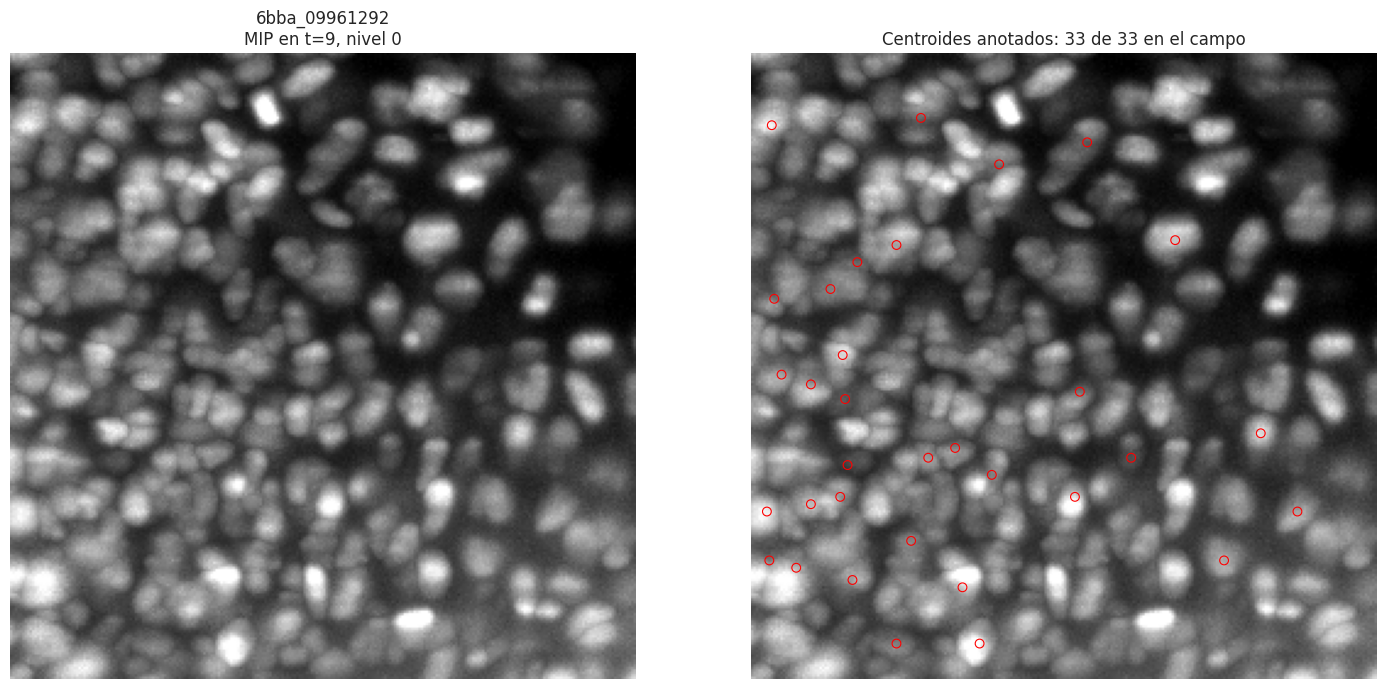

In [28]:
# --- Proyección de máxima intensidad con los centroides anotados encima ------
arr = zarr.open(str(TRAIN_DIR / f"{VIS_SAMPLE}.zarr" / VIS_LEVEL), mode="r")
y0, y1 = crop_y if crop_y else (0, meta["shape"][2])
x0, x1 = crop_x if crop_x else (0, meta["shape"][3])
vol = np.asarray(arr[VIS_T, :, y0:y1, x0:x1])
mip = vol.max(axis=0)

# Los centroides están en píxeles del nivel 0: se reescalan al nivel descargado.
shape0 = niveles["0"]["shape"] if "0" in niveles else meta["shape"]
fy, fx = shape0[2] / meta["shape"][2], shape0[3] / meta["shape"][3]

n = df_nodes[(df_nodes["sample"] == VIS_SAMPLE) & (df_nodes["t"] == VIS_T)]
py, px = n["y"] / fy - y0, n["x"] / fx - x0
dentro = (py >= 0) & (py < mip.shape[0]) & (px >= 0) & (px < mip.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[0].set_title(f"{VIS_SAMPLE}\nMIP en t={VIS_T}, nivel {VIS_LEVEL}"); ax[0].axis("off")

ax[1].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[1].scatter(px[dentro], py[dentro], s=40, facecolor="none", edgecolor="red", lw=.8)
ax[1].set_title(f"Centroides anotados: {int(dentro.sum())} de {len(n)} en el campo")
ax[1].axis("off")
plt.tight_layout(); plt.show()

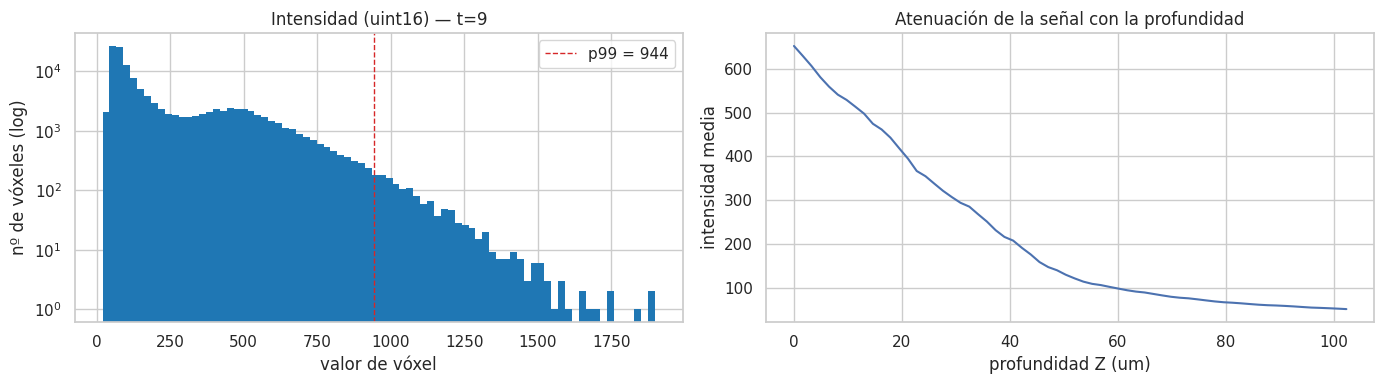

Rango: 15 – 2052 (3.1% del rango del uint16)
Mediana (fondo): 110 | p99: 944 | p99.9: 1262
Vóxeles por encima del p99: 1.00%
Atenuación: la intensidad media cae de 652 en la superficie a 52 en el fondo (92% de pérdida)


In [29]:
# --- Distribución de intensidades -------------------------------------------
muestra_px = np.asarray(vol[::2, ::4, ::4]).ravel()
p99 = np.percentile(muestra_px, 99)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(muestra_px, bins=80, log=True, color="tab:blue", edgecolor="none")
ax[0].axvline(p99, ls="--", lw=1, color="tab:red", label=f"p99 = {p99:.0f}")
ax[0].set_title(f"Intensidad ({vol.dtype}) — t={VIS_T}")
ax[0].set_xlabel("valor de vóxel"); ax[0].set_ylabel("nº de vóxeles (log)")
ax[0].legend()

perfil = vol.reshape(vol.shape[0], -1).mean(axis=1)
ax[1].plot(np.arange(len(perfil)) * VOXEL_UM[0] * (shape0[1] / meta["shape"][1]), perfil)
ax[1].set_xlabel("profundidad Z (um)"); ax[1].set_ylabel("intensidad media")
ax[1].set_title("Atenuación de la señal con la profundidad")

plt.tight_layout(); plt.show()

print(f"Rango: {vol.min()} – {vol.max()} ({(vol.max()/65535)*100:.1f}% del rango del uint16)")
print(f"Mediana (fondo): {np.median(muestra_px):.0f} | p99: {p99:.0f} | "
      f"p99.9: {np.percentile(muestra_px, 99.9):.0f}")
print(f"Vóxeles por encima del p99: {(muestra_px > p99).mean()*100:.2f}%")
print(f"Atenuación: la intensidad media cae de {perfil[0]:.0f} en la superficie "
      f"a {perfil[-1]:.0f} en el fondo ({(1-perfil[-1]/perfil[0])*100:.0f}% de pérdida)")

In [30]:
# Resumen numérico listo para copiar al informe
e1 = df_edges[df_edges.dt == 1]
nodos_por_t = df_nodes.groupby(["sample", "t"]).size()
dims = tuple(int(v) for v in df_samples.iloc[0][["T", "Z", "Y", "X"]])
dtipo = df_samples["dtype"].iloc[0]
tasa_div = df_nodes["es_division"].mean()
dens_glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100

por_embrion = (df_nodes.groupby("embryo_id").size().rename("nodos").to_frame()
               .join(e1.groupby("embryo_id")["dist_um"].median().rename("desplaz_mediana_um"))
               .round(2).to_string())

print(f"""
DATOS ANALIZADOS
  Muestras: {len(df_samples)} de {df_samples.embryo_id.nunique()} embriones distintos
  Dimensiones (T, Z, Y, X): {dims} | dtype: {dtipo}
  Escala del vóxel: {tuple(VOXEL_UM.tolist())} um -> anisotropía {VOXEL_UM[0]/VOXEL_UM[1]:.0f}x en Z
  Nodos: {len(df_nodes):,} | Aristas: {len(df_edges):,} | Linajes: {len(df_linajes):,}

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana {nodos_por_t.median():.0f} (rango {nodos_por_t.min()}-{nodos_por_t.max()})
  Cobertura temporal media: {df_samples.cobertura_temporal.mean()*100:.1f}% de los frames del video
  Densidad de anotación global: {dens_glob:.2f}% de las células estimadas
    (por muestra: {df_samples.densidad_anotacion.min():.2f}% - {df_samples.densidad_anotacion.max():.2f}%)
  Aristas por nodo: {df_samples.aristas_por_nodo.mean():.2f}

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana {e1.dist_um.median():.2f} um | p95 {e1.dist_um.quantile(.95):.2f} um
                  p99 {e1.dist_um.quantile(.99):.2f} um | máximo {e1.dist_um.max():.2f} um
  Duración de linajes: mediana {df_linajes.duracion.median():.0f} frames | máx {df_linajes.duracion.max():.0f}

DIVISIONES
  {int(df_nodes.es_division.sum()):,} eventos = {tasa_div*100:.3f}% de los nodos
  Desbalance aproximado 1:{int(1/max(tasa_div, 1e-9)):,}

VARIABILIDAD ENTRE EMBRIONES
{por_embrion}
""")


DATOS ANALIZADOS
  Muestras: 199 de 2 embriones distintos
  Dimensiones (T, Z, Y, X): (100, 64, 256, 256) | dtype: uint16
  Escala del vóxel: (1.625, 0.40625, 0.40625) um -> anisotropía 4x en Z
  Nodos: 133,318 | Aristas: 128,883 | Linajes: 4,435

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana 6 (rango 1-33)
  Cobertura temporal media: 95.1% de los frames del video
  Densidad de anotación global: 2.82% de las células estimadas
    (por muestra: 0.13% - 20.21%)
  Aristas por nodo: 0.97

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana 1.82 um | p95 5.34 um
                  p99 8.38 um | máximo 60.76 um
  Duración de linajes: mediana 21 frames | máx 100

DIVISIONES
  151 eventos = 0.113% de los nodos
  Desbalance aproximado 1:882

VARIABILIDAD ENTRE EMBRIONES
            nodos  desplaz_mediana_um
embryo_id                            
44b6        20197                1.72
6bba       113121                1.82

